<a href="https://colab.research.google.com/github/LamponeHub/System-Analysis/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22EDA_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. подключение библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Загрузим набор

In [ ]:
data = pd.read_csv("used_cars_data.csv")
data.head(5)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [ ]:
data.tail()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,NaN
7249,7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7252,7252,Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...,Kochi,2014,72443,Diesel,Automatic,First,10.0 kmpl,2148 CC,170 bhp,5.0,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


In [ ]:
data.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


In [ ]:
data.nunique()



,0
S.No.,7253
Name,2041
Location,11
Year,23
Kilometers_Driven,3660
Fuel_Type,5
Transmission,2
Owner_Type,4
Mileage,450
Engine,150


In [ ]:
data[data.duplicated()]


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price


In [ ]:
data = data.drop(['S.No.'], axis = 1)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               7253 non-null   object 
 1   Location           7253 non-null   object 
 2   Year               7253 non-null   int64  
 3   Kilometers_Driven  7253 non-null   int64  
 4   Fuel_Type          7253 non-null   object 
 5   Transmission       7253 non-null   object 
 6   Owner_Type         7253 non-null   object 
 7   Mileage            7251 non-null   object 
 8   Engine             7207 non-null   object 
 9   Power              7207 non-null   object 
 10  Seats              7200 non-null   float64
 11  New_Price          1006 non-null   object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 736.8+ KB


In [ ]:
from datetime import date
date.today().year
data['Car_Age']=date.today().year-data['Year']
data.head()


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,15
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,10
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,14
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,13
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,12


In [ ]:
data['Brand'] = data.Name.str.split().str.get(0)
data['Model'] = data.Name.str.split().str.get(1) + data.Name.str.split().str.get(2)
data.sample(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model
5944,Ford EcoSport 1.0 Ecoboost Titanium Plus,Delhi,2015,64000,Petrol,Manual,First,18.88 kmpl,999 CC,123.24 bhp,5.0,NaN,6.00,10,Ford,EcoSport1.0
6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,7.88 Lakh,4.75,11,Maruti,SwiftVDI
2859,Renault KWID Climber 1.0 MT,Hyderabad,2018,4126,Petrol,Manual,First,21.7 kmpl,999 CC,67 bhp,5.0,5.3 Lakh,4.80,7,Renault,KWIDClimber
691,Hyundai EON Era Plus,Kochi,2016,36700,Petrol,Manual,First,21.1 kmpl,814 CC,55.2 bhp,5.0,NaN,4.38,9,Hyundai,EONEra
7240,Honda Jazz 1.5 V i DTEC,Coimbatore,2017,44556,Diesel,Manual,First,27.3 kmpl,1498 CC,98.6 bhp,5.0,NaN,NaN,8,Honda,Jazz1.5
1439,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,Hyderabad,2012,131000,Diesel,Manual,First,12.99 kmpl,2494 CC,100 bhp,7.0,NaN,9.60,13,Toyota,Innova2.5
3581,BMW 3 Series Luxury Line,Ahmedabad,2016,27000,Diesel,Automatic,First,21.76 kmpl,1995 CC,190 bhp,5.0,55.07 Lakh,35.00,9,BMW,3Series
2743,Mahindra XUV500 W8 2WD,Bangalore,2015,76000,Diesel,Manual,Second,16.0 kmpl,2179 CC,140 bhp,7.0,NaN,12.00,10,Mahindra,XUV500W8
182,BMW 5 Series 520d Luxury Line,Hyderabad,2014,51000,Diesel,Automatic,First,22.48 kmpl,1995 CC,190 bhp,5.0,69.47 Lakh,33.50,11,BMW,5Series
2798,Mahindra TUV 300 2015-2019 T8,Coimbatore,2017,49404,Diesel,Manual,First,18.49 kmpl,1493 CC,100 bhp,7.0,NaN,7.36,8,Mahindra,TUV300


In [ ]:
print(data.Brand.unique())

['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'Isuzu' 'ISUZU' 'Force' 'Bentley'
 'Lamborghini' 'Hindustan' 'OpelCorsa']


In [ ]:
data["Brand"] = data["Brand"].replace({"ISUZU": "Isuzu", "Mini": "Mini Cooper","Land":"Land Rover"})

del data['Name']

In [ ]:
data

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,15,Maruti,WagonR
1,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,10,Hyundai,Creta1.6
2,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,14,Honda,JazzV
3,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,13,Maruti,ErtigaVDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,12,Audi,A4New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,Hyderabad,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,NaN,14,Volkswagen,VentoDiesel
7249,Mumbai,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN,10,Volkswagen,PoloGT
7250,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,NaN,13,Nissan,MicraDiesel
7251,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN,12,Volkswagen,PoloGT


In [ ]:
data['Mileage_num'] = data.Mileage.str.split().str.get(0)
data['Mileage_units'] = data.Mileage.str.split().str.get(1)
data['Mileage_num'] = data['Mileage_num'].astype(float)

In [ ]:
data

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model,Mileage_num,Mileage_units
0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,15,Maruti,WagonR,26.60,km/kg
1,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,10,Hyundai,Creta1.6,19.67,kmpl
2,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,14,Honda,JazzV,18.20,kmpl
3,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,13,Maruti,ErtigaVDI,20.77,kmpl
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,12,Audi,A4New,15.20,kmpl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,Hyderabad,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,NaN,14,Volkswagen,VentoDiesel,20.54,kmpl
7249,Mumbai,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN,10,Volkswagen,PoloGT,17.21,kmpl
7250,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,NaN,13,Nissan,MicraDiesel,23.08,kmpl
7251,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN,12,Volkswagen,PoloGT,17.20,kmpl


In [ ]:
print(data.isnull().sum())
print(data.Mileage_units.unique())
print(data.info())

Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
Car_Age                 0
Brand                   0
Model                   1
Mileage_num             2
Mileage_units           2
dtype: int64
['km/kg' 'kmpl' nan]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           7253 non-null   object 
 1   Year               7253 non-null   int64  
 2   Kilometers_Driven  7253 non-null   int64  
 3   Fuel_Type          7253 non-null   object 
 4   Transmission       7253 non-null   object 
 5   Owner_Type         7253 non-null   object 
 6   Mileage            7251 non-

In [ ]:
data['Mileage'] = data['Mileage_num']*(1+0.333*(data['Mileage_units']=='km/kg'))
del data['Mileage_num']
del data['Mileage_units']
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           7253 non-null   object 
 1   Year               7253 non-null   int64  
 2   Kilometers_Driven  7253 non-null   int64  
 3   Fuel_Type          7253 non-null   object 
 4   Transmission       7253 non-null   object 
 5   Owner_Type         7253 non-null   object 
 6   Mileage            7251 non-null   float64
 7   Engine             7207 non-null   object 
 8   Power              7207 non-null   object 
 9   Seats              7200 non-null   float64
 10  New_Price          1006 non-null   object 
 11  Price              6019 non-null   float64
 12  Car_Age            7253 non-null   int64  
 13  Brand              7253 non-null   object 
 14  Model              7252 non-null   object 
dtypes: float64(3), int64(3), object(9)
memory usage: 850.1+ KB
None


In [ ]:
data

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,35.4578,998 CC,58.16 bhp,5.0,NaN,1.75,15,Maruti,WagonR
1,Pune,2015,41000,Diesel,Manual,First,19.6700,1582 CC,126.2 bhp,5.0,NaN,12.50,10,Hyundai,Creta1.6
2,Chennai,2011,46000,Petrol,Manual,First,18.2000,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,14,Honda,JazzV
3,Chennai,2012,87000,Diesel,Manual,First,20.7700,1248 CC,88.76 bhp,7.0,NaN,6.00,13,Maruti,ErtigaVDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2000,1968 CC,140.8 bhp,5.0,NaN,17.74,12,Audi,A4New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,Hyderabad,2011,89411,Diesel,Manual,First,20.5400,1598 CC,103.6 bhp,5.0,NaN,NaN,14,Volkswagen,VentoDiesel
7249,Mumbai,2015,59000,Petrol,Automatic,First,17.2100,1197 CC,103.6 bhp,5.0,NaN,NaN,10,Volkswagen,PoloGT
7250,Kolkata,2012,28000,Diesel,Manual,First,23.0800,1461 CC,63.1 bhp,5.0,NaN,NaN,13,Nissan,MicraDiesel
7251,Pune,2013,52262,Petrol,Automatic,Third,17.2000,1197 CC,103.6 bhp,5.0,NaN,NaN,12,Volkswagen,PoloGT


In [ ]:
print(data.Fuel_Type.unique())

['CNG' 'Diesel' 'Petrol' 'LPG' 'Electric']


In [ ]:
print(data.Transmission.unique())


['Manual' 'Automatic']


In [ ]:
print(data.Owner_Type.unique())

['First' 'Second' 'Fourth & Above' 'Third']


In [ ]:
#решение про Engine
data['Engine_num'] = data.Engine.str.split().str.get(0)
data['Engine'] = data[Engine_num'].astype(float)
del data['Engine_num']


In [ ]:
data['Power_num'] = data.Power.str.split().str.get(0)
#data['Power'] = data['Power_num'].astype(float)
#скорее всего, студенты попытаются просто повторить предыдущий код. эта строка пока вызовет ошибку, потому что в столбце пустые значения обозначены строкой 'null'
data['Power_num'] = data['Power_num'].replace({"null": np.nan})
data['Power'] = data['Power_num'].astype(float)
del data['Power_num']


In [ ]:
data

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,35.4578,998.0,58.16,5.0,NaN,1.75,15,Maruti,WagonR
1,Pune,2015,41000,Diesel,Manual,First,19.6700,1582.0,126.20,5.0,NaN,12.50,10,Hyundai,Creta1.6
2,Chennai,2011,46000,Petrol,Manual,First,18.2000,1199.0,88.70,5.0,8.61 Lakh,4.50,14,Honda,JazzV
3,Chennai,2012,87000,Diesel,Manual,First,20.7700,1248.0,88.76,7.0,NaN,6.00,13,Maruti,ErtigaVDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2000,1968.0,140.80,5.0,NaN,17.74,12,Audi,A4New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,Hyderabad,2011,89411,Diesel,Manual,First,20.5400,1598.0,103.60,5.0,NaN,NaN,14,Volkswagen,VentoDiesel
7249,Mumbai,2015,59000,Petrol,Automatic,First,17.2100,1197.0,103.60,5.0,NaN,NaN,10,Volkswagen,PoloGT
7250,Kolkata,2012,28000,Diesel,Manual,First,23.0800,1461.0,63.10,5.0,NaN,NaN,13,Nissan,MicraDiesel
7251,Pune,2013,52262,Petrol,Automatic,Third,17.2000,1197.0,103.60,5.0,NaN,NaN,12,Volkswagen,PoloGT


In [ ]:
#решение про New_Price
data['New_Price_num'] = data.New_Price.str.split().str.get(0)
data['New_Price_units'] = data.New_Price.str.split().str.get(1)
data['New_Price_units'].unique()
#Здесь нужно будет объяснить, что Lakh - это 100 000 рупий, та же единица, в которых указана и Price. а Сr - это 10 000 000 рупий. Поэтому Lakh можно просто отбросить, а CR нужно пересчитывать
data['New_Price_num'] = data['New_Price_num'].astype(float)
data['New_Price'] = np.where(data['New_Price_units'] == 'Cr', data['New_Price_num'] * 100, data['New_Price_num'])
del data['New_Price_num']
del data['New_Price_units']

In [ ]:
data.describe()



,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age
count,7253.000000,7.253000e+03,7251.000000,7207.000000,7078.000000,7200.000000,1006.000000,6019.000000,7253.000000
mean,2013.365366,5.869906e+04,18.224336,1616.573470,112.765214,5.279722,22.779692,9.479468,11.634634
std,3.254421,8.442772e+04,4.779547,595.285137,53.493553,0.811660,27.759344,11.187917,3.254421
min,1996.000000,1.710000e+02,0.000000,72.000000,34.200000,0.000000,3.910000,0.440000,6.000000
25%,2011.000000,3.400000e+04,15.260000,1198.000000,75.000000,5.000000,7.885000,3.500000,9.000000
50%,2014.000000,5.341600e+04,18.190000,1493.000000,94.000000,5.000000,11.570000,5.640000,11.000000
75%,2016.000000,7.300000e+04,21.100000,1968.000000,138.100000,5.000000,26.042500,9.950000,14.000000
max,2019.000000,6.500000e+06,44.708820,5998.000000,616.000000,10.000000,375.000000,160.000000,29.000000


In [ ]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location,7253,11,Mumbai,949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,7253.0,NaN,NaN,NaN,2013.365366,3.254421,1996.0,2011.0,2014.0,2016.0,2019.0
Kilometers_Driven,7253.0,NaN,NaN,NaN,58699.063146,84427.720583,171.0,34000.0,53416.0,73000.0,6500000.0
Fuel_Type,7253,5,Diesel,3852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,7253,2,Manual,5204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner_Type,7253,4,First,5952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,7251.0,NaN,NaN,NaN,18.224336,4.779547,0.0,15.26,18.19,21.1,44.70882
Engine,7207.0,NaN,NaN,NaN,1616.57347,595.285137,72.0,1198.0,1493.0,1968.0,5998.0
Power,7078.0,NaN,NaN,NaN,112.765214,53.493553,34.2,75.0,94.0,138.1,616.0
Seats,7200.0,NaN,NaN,NaN,5.279722,0.81166,0.0,5.0,5.0,5.0,10.0


In [ ]:
cat_cols=data.select_dtypes(include=['object']).columns.tolist()
num_cols = data.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)


Categorical Variables:
['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand', 'Model']


In [ ]:
print("Numerical Variables:")
print(num_cols)

Numerical Variables:
['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price', 'Car_Age']


Year


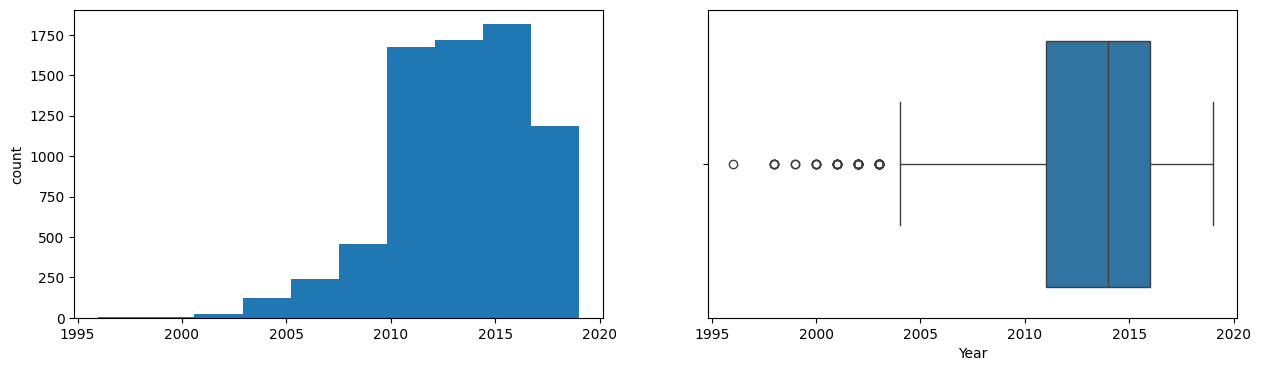

Kilometers_Driven


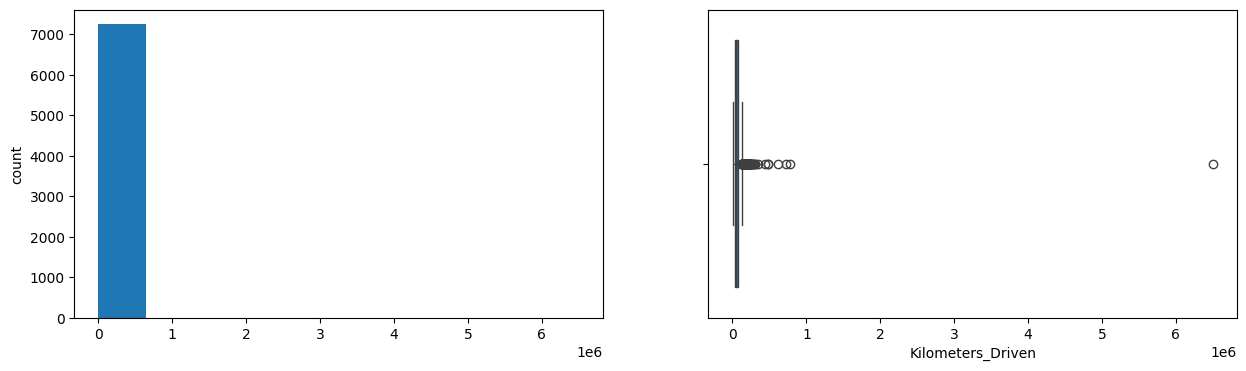

Mileage


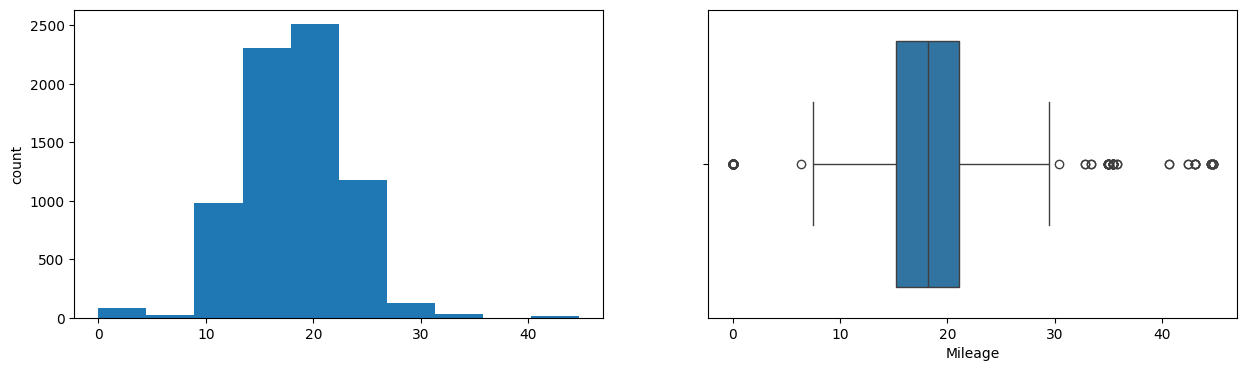

Engine


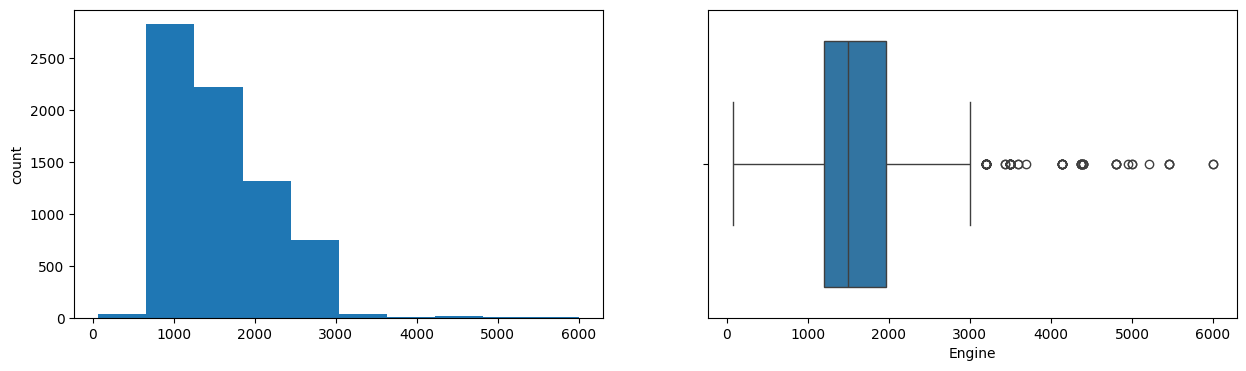

Power


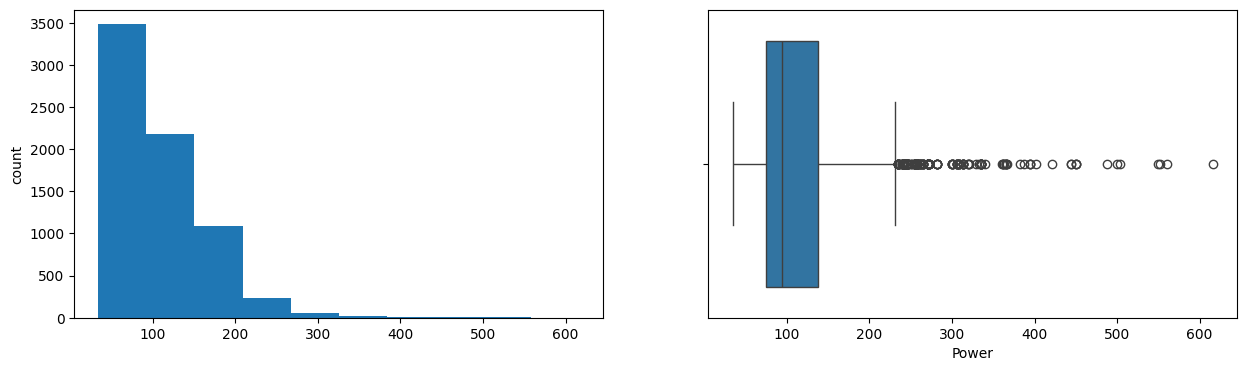

Seats


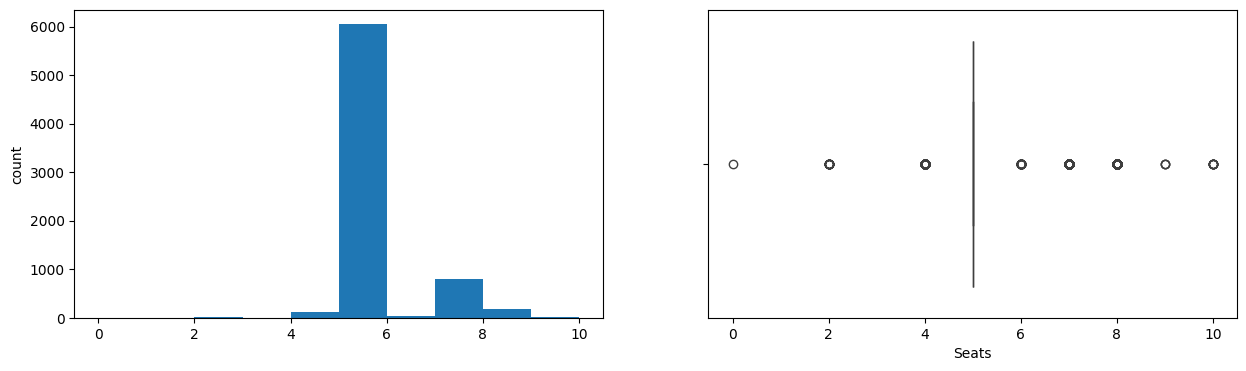

New_Price


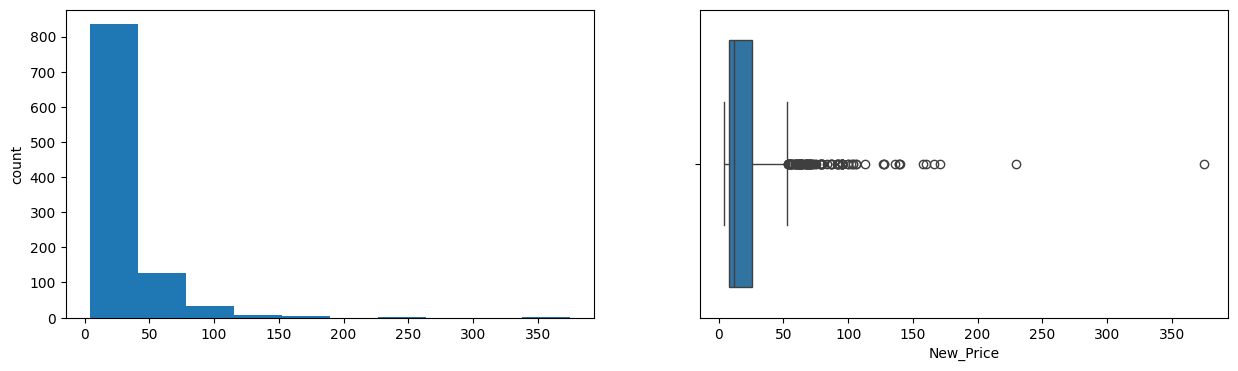

Price


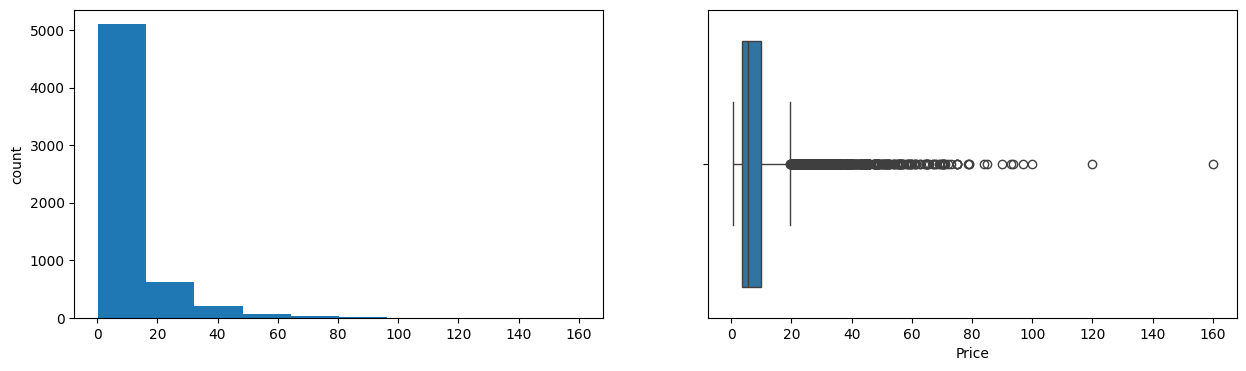

Car_Age


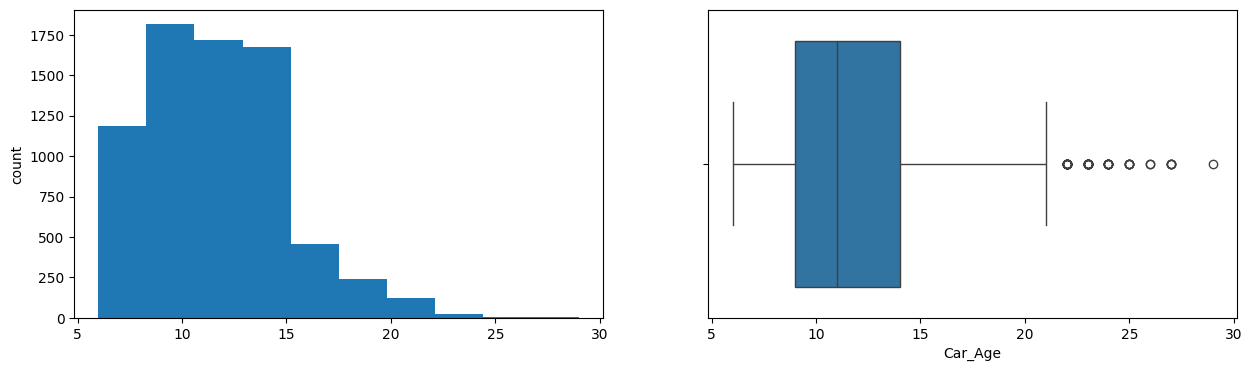

In [ ]:
for col in num_cols:
    print(col)
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    data[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col])
    plt.show()


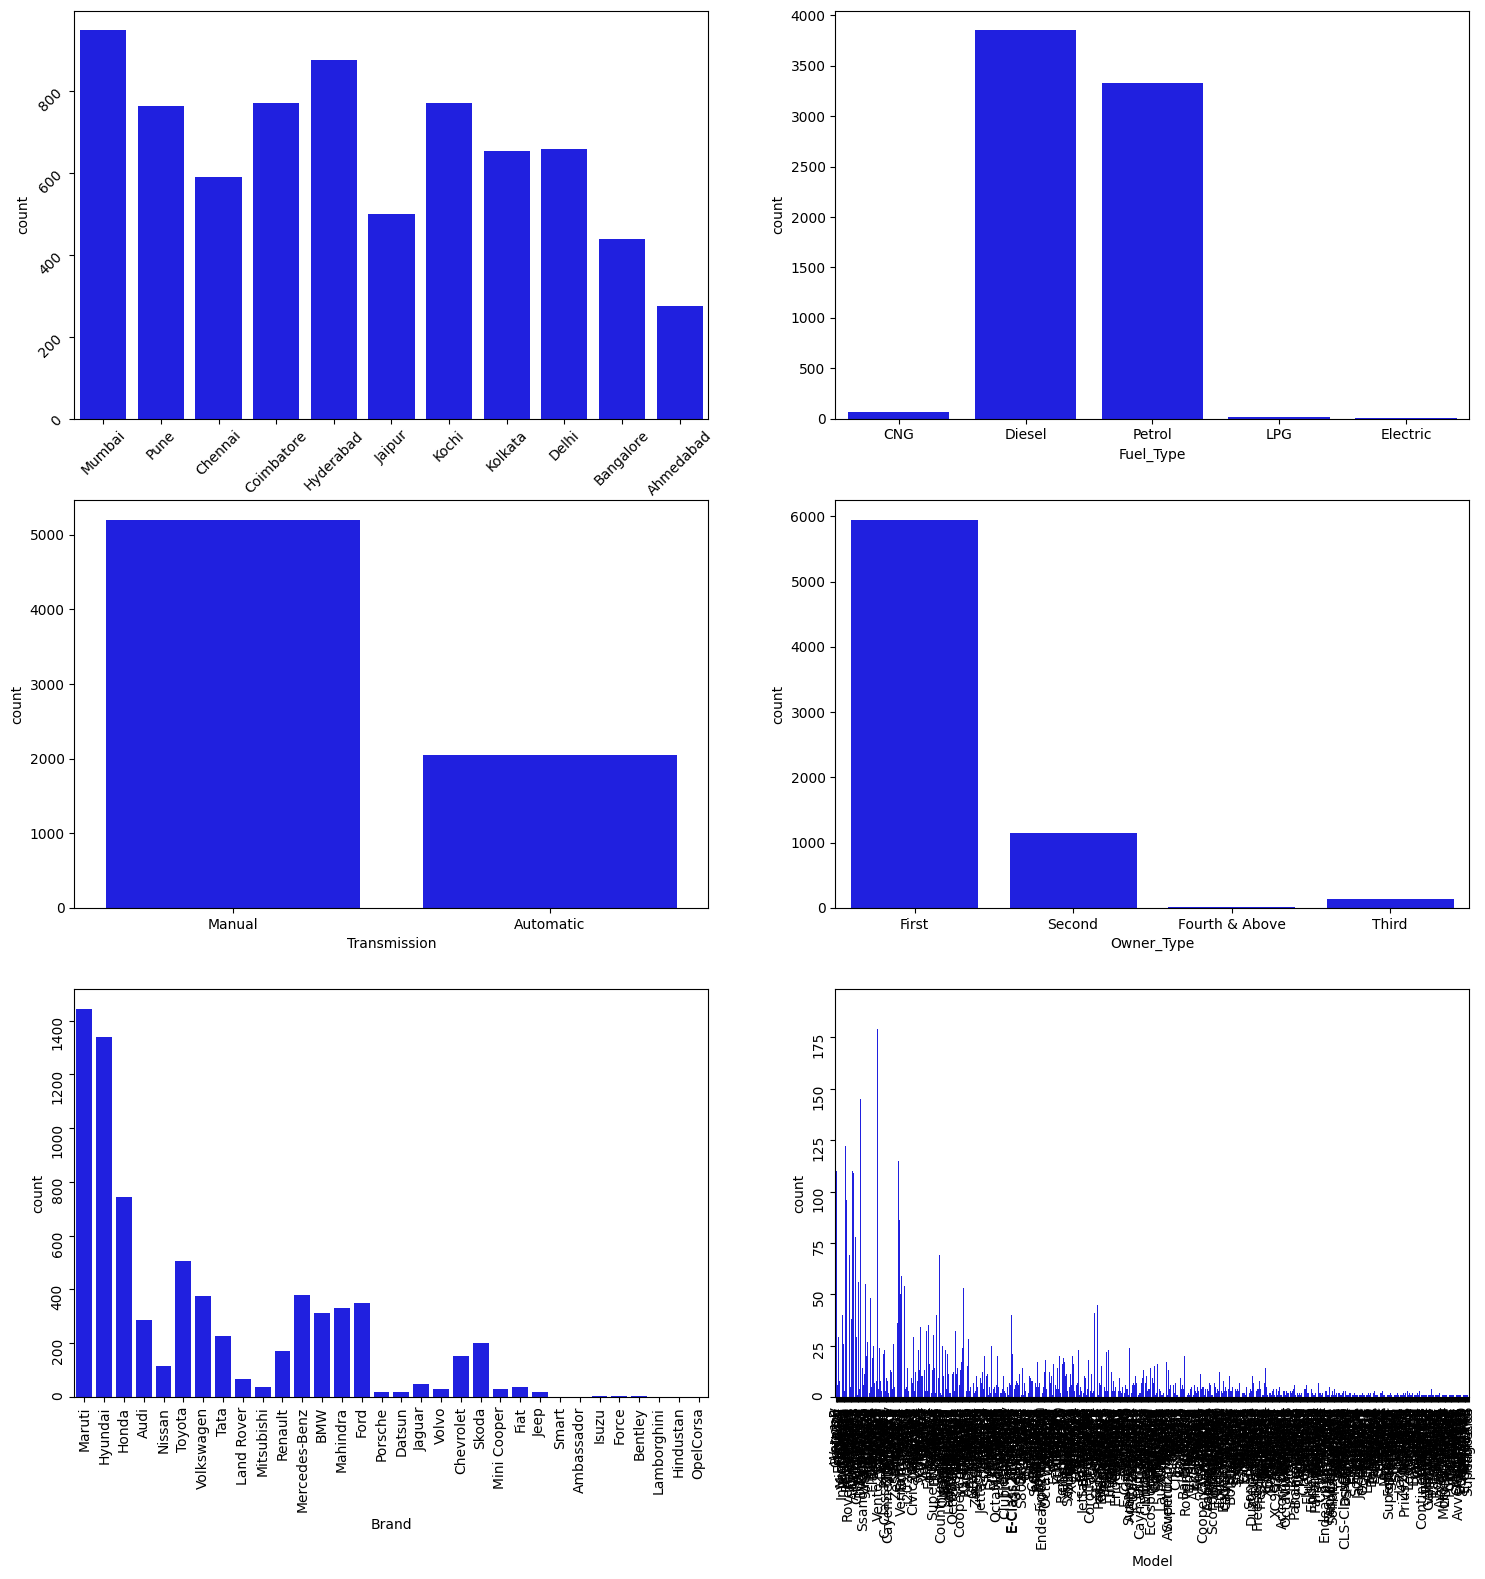

In [ ]:
fig, axes = plt.subplots(3, 2, figsize = (18, 18))
for i in range(len(cat_cols)):
    sns.countplot(ax = axes[i//2, i%2], x = cat_cols[i], data = data, color = 'blue')
axes[0][0].tick_params(labelrotation=45)
axes[2][0].tick_params(labelrotation=90)
axes[2][1].tick_params(labelrotation=90)
plt.show()


In [ ]:
for colname in ['Kilometers_Driven','Price']:
        data[colname + '_log'] = np.log1p(data[colname])


In [ ]:
data

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model,Kilometers_Driven_log,Price_log
0,Mumbai,2010,72000,CNG,Manual,First,35.4578,998.0,58.16,5.0,NaN,1.75,15,Maruti,WagonR,11.184435,1.011601
1,Pune,2015,41000,Diesel,Manual,First,19.6700,1582.0,126.20,5.0,NaN,12.50,10,Hyundai,Creta1.6,10.621352,2.602690
2,Chennai,2011,46000,Petrol,Manual,First,18.2000,1199.0,88.70,5.0,8.61,4.50,14,Honda,JazzV,10.736418,1.704748
3,Chennai,2012,87000,Diesel,Manual,First,20.7700,1248.0,88.76,7.0,NaN,6.00,13,Maruti,ErtigaVDI,11.373675,1.945910
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2000,1968.0,140.80,5.0,NaN,17.74,12,Audi,A4New,10.613271,2.930660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,Hyderabad,2011,89411,Diesel,Manual,First,20.5400,1598.0,103.60,5.0,NaN,NaN,14,Volkswagen,VentoDiesel,11.401010,NaN
7249,Mumbai,2015,59000,Petrol,Automatic,First,17.2100,1197.0,103.60,5.0,NaN,NaN,10,Volkswagen,PoloGT,10.985310,NaN
7250,Kolkata,2012,28000,Diesel,Manual,First,23.0800,1461.0,63.10,5.0,NaN,NaN,13,Nissan,MicraDiesel,10.239996,NaN
7251,Pune,2013,52262,Petrol,Automatic,Third,17.2000,1197.0,103.60,5.0,NaN,NaN,12,Volkswagen,PoloGT,10.864044,NaN


<Figure size 1300x1700 with 0 Axes>

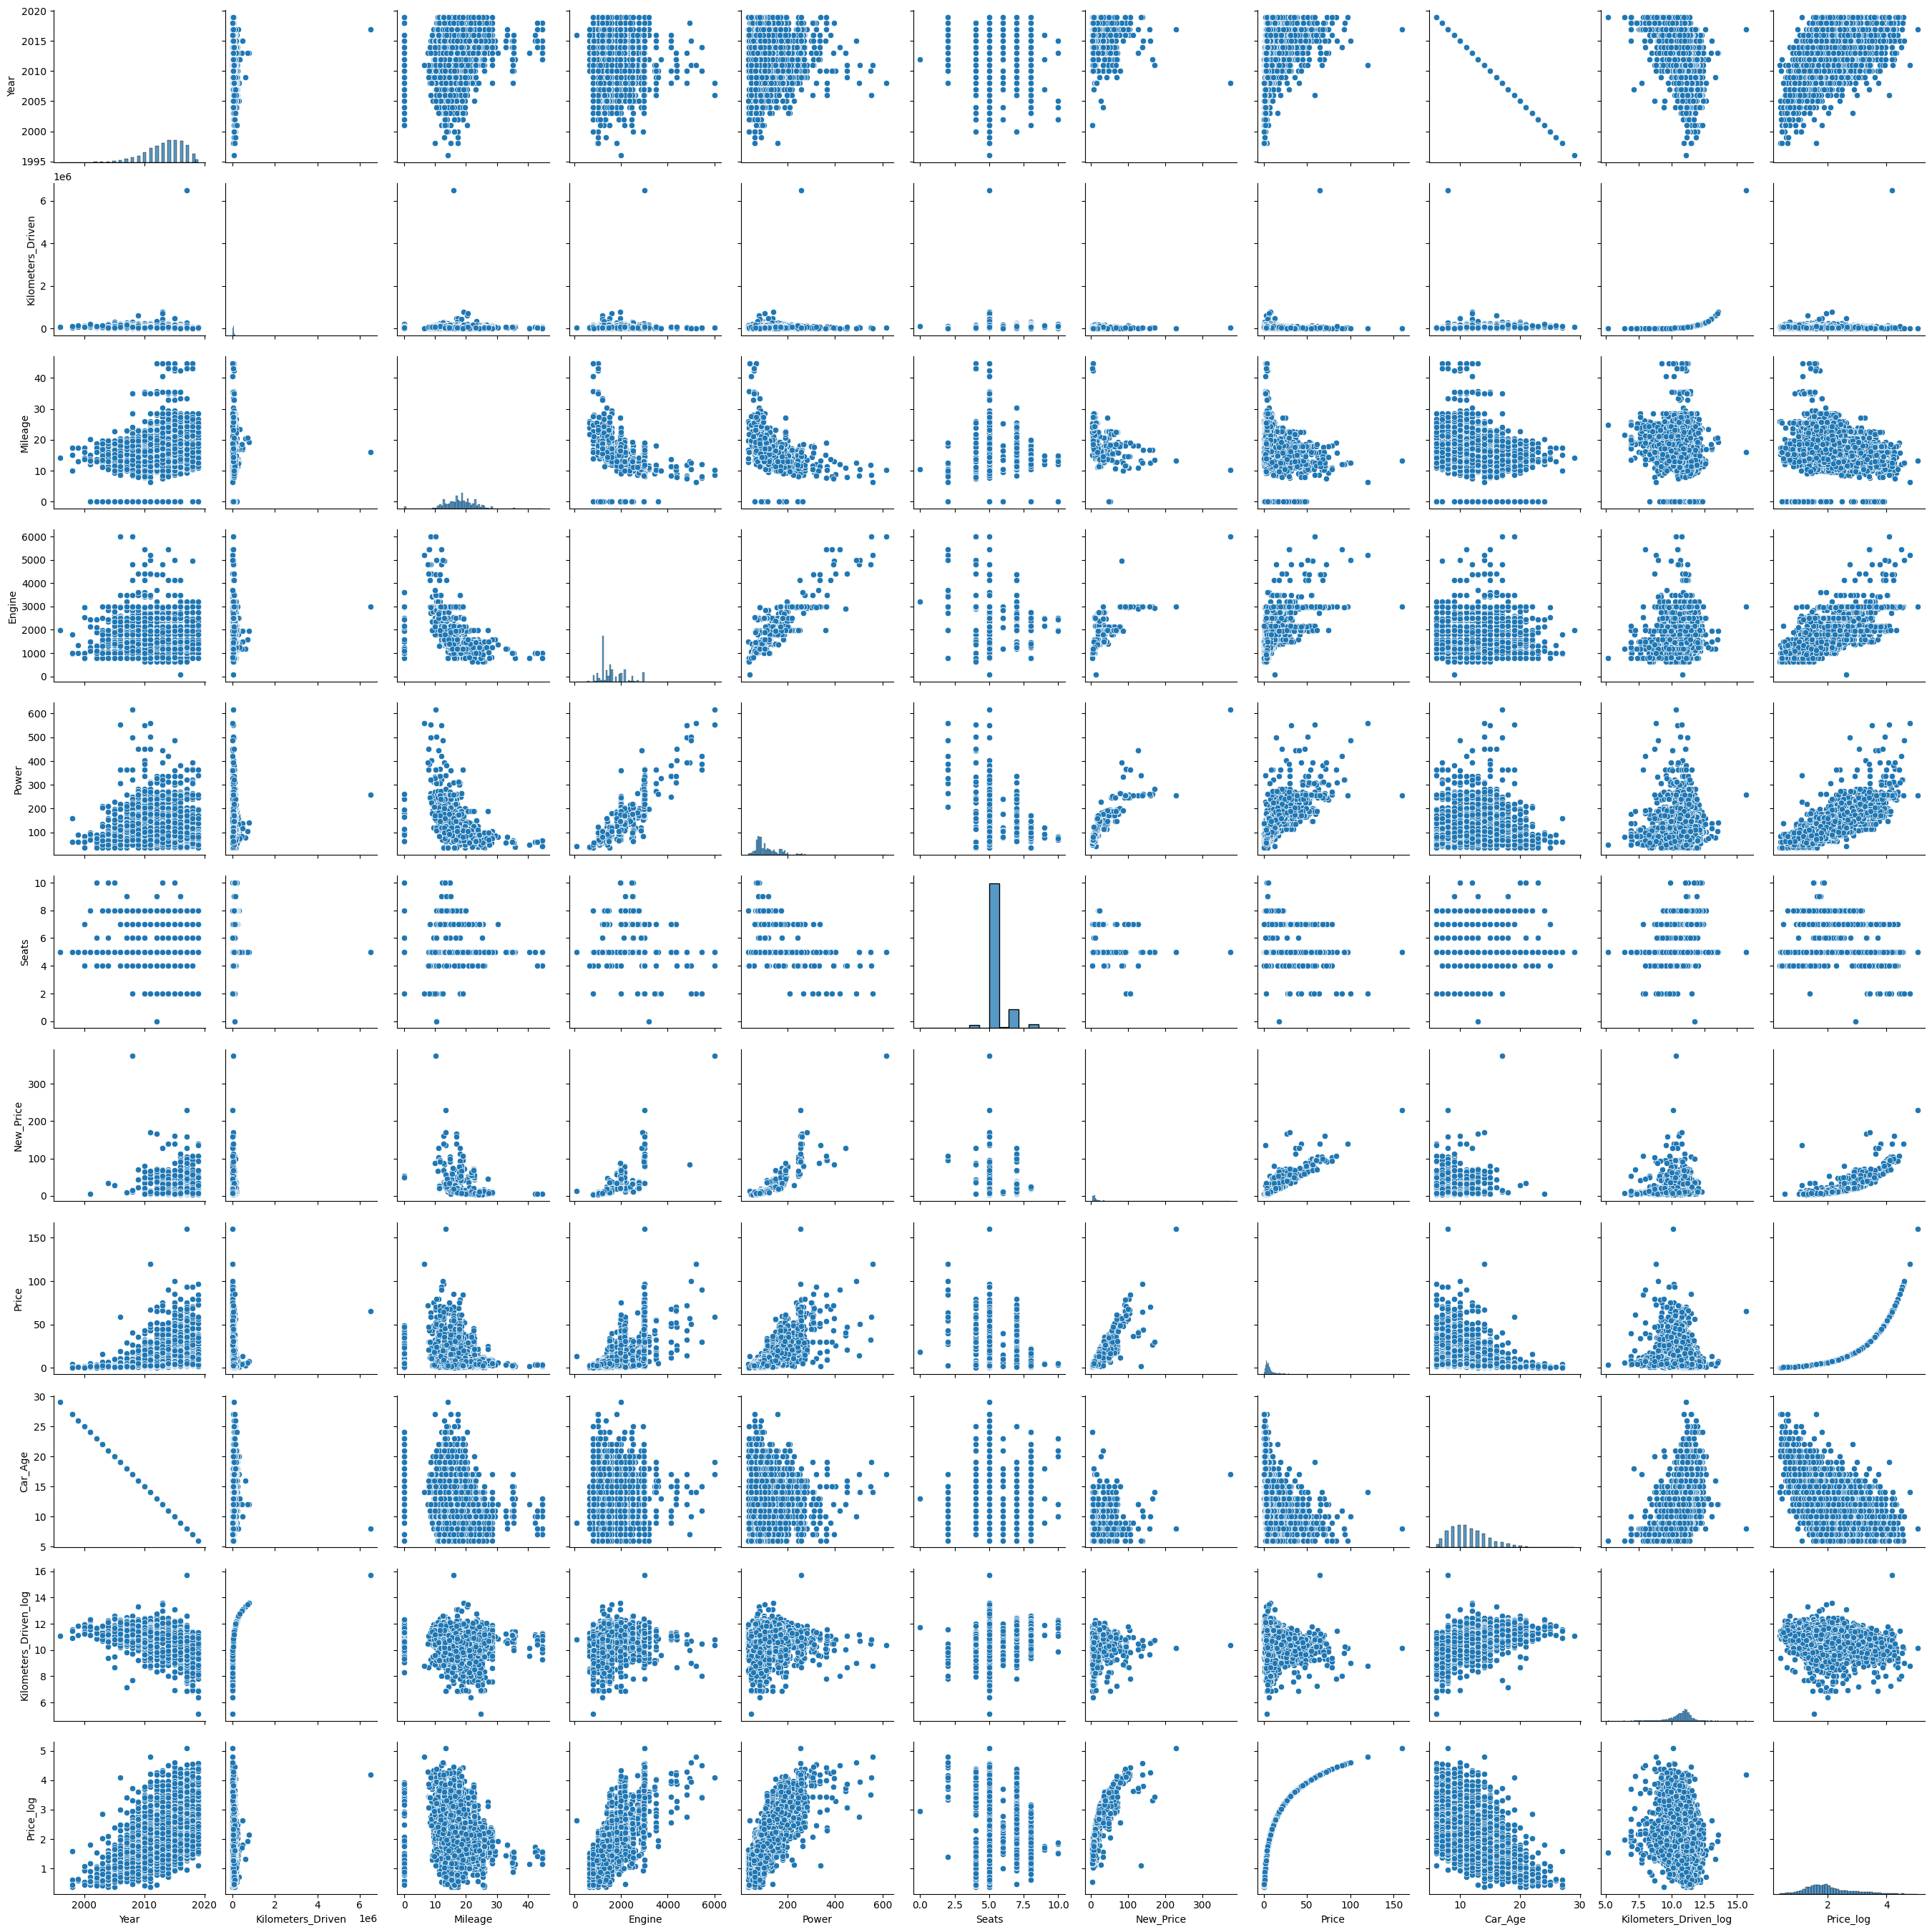

In [ ]:
plt.figure(figsize=(13,17))
sns.pairplot(data)
plt.show()


<Figure size 1300x1700 with 0 Axes>

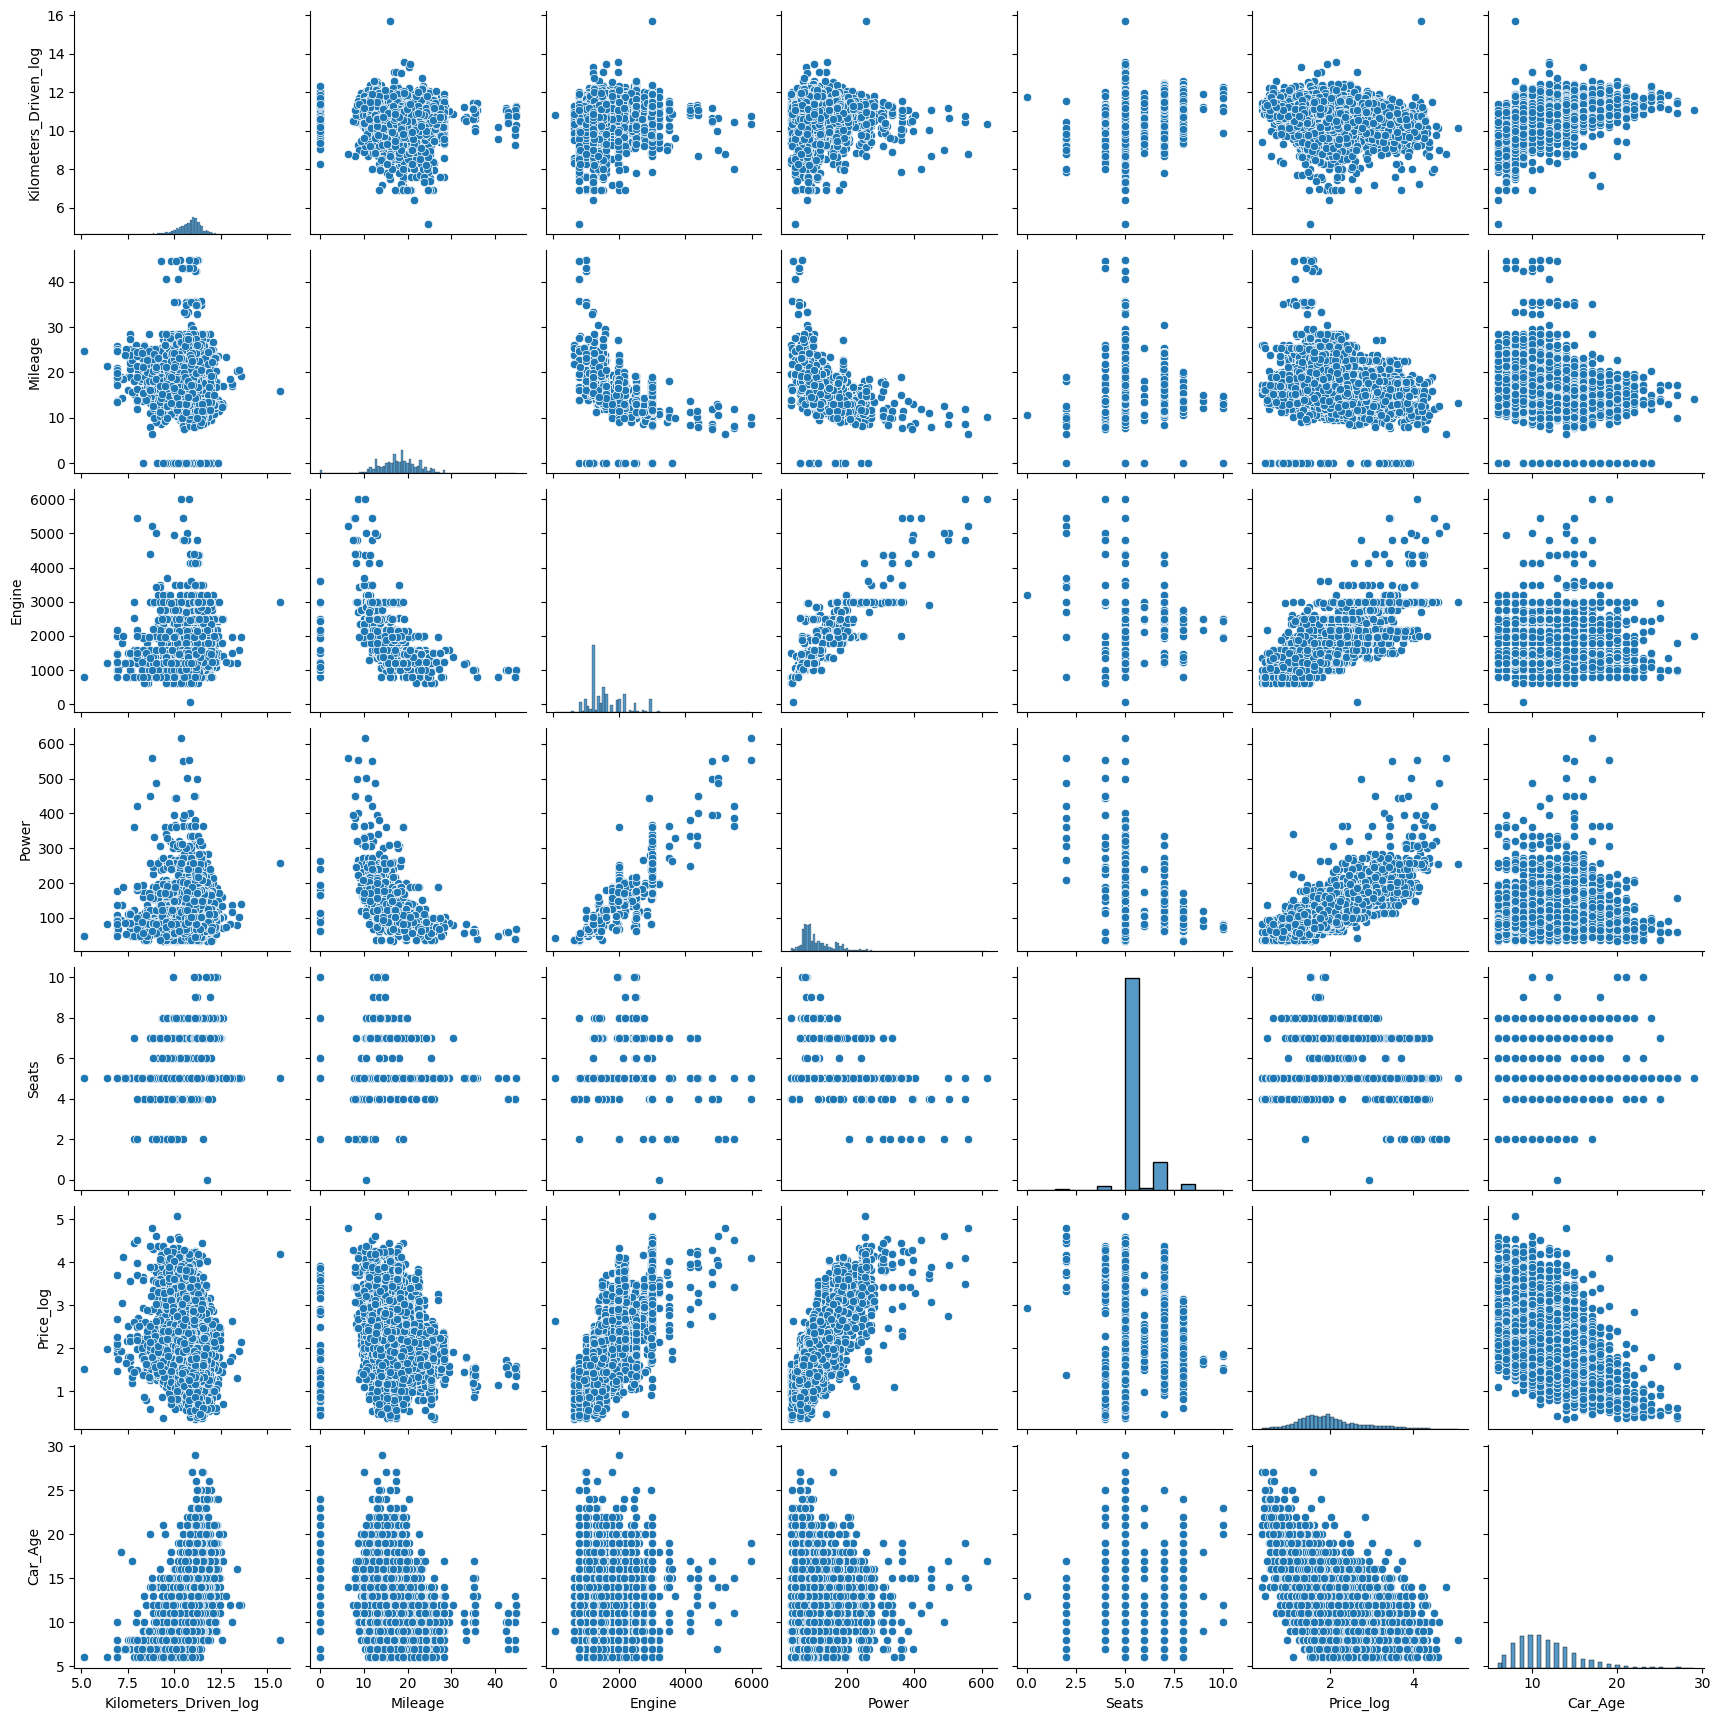

In [ ]:
plt.figure(figsize=(13,17))
sns.pairplot(data[['Kilometers_Driven_log', 'Mileage', 'Engine', 'Power', 'Seats', 'Price_log', 'Car_Age']])
plt.show()


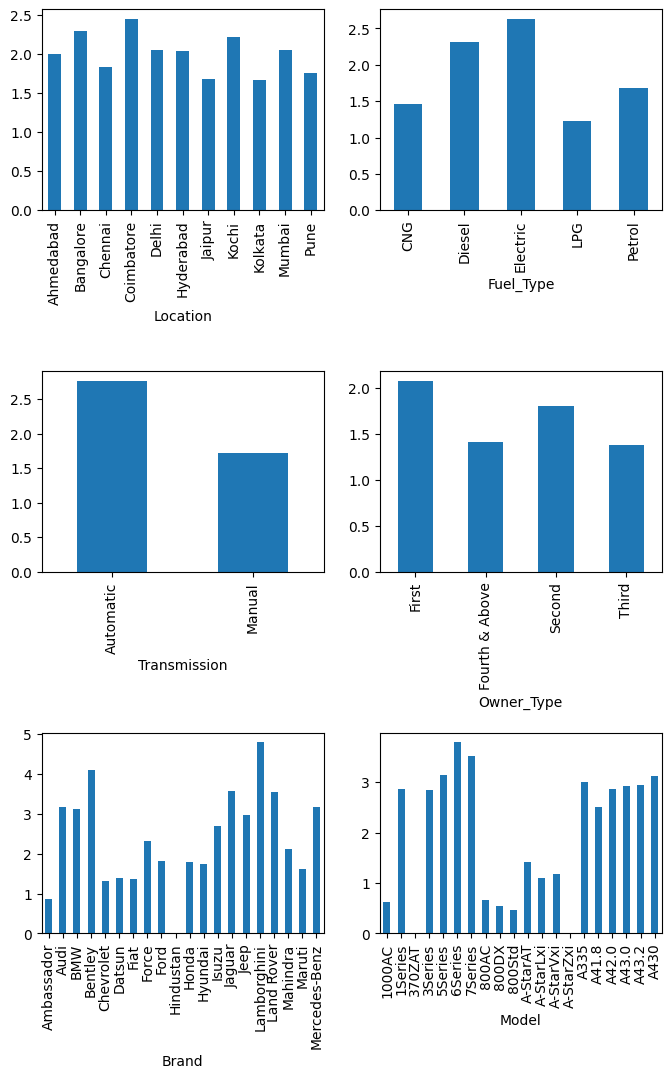

In [ ]:
fig, axarr = plt.subplots(3, 2, figsize=(8, 12))
for i in range(len(cat_cols)):
    data.groupby(cat_cols[i])['Price_log'].mean().\
    head(20).plot.bar(ax=axarr[i//2][i%2])
plt.subplots_adjust(hspace=0.8)
plt.show()


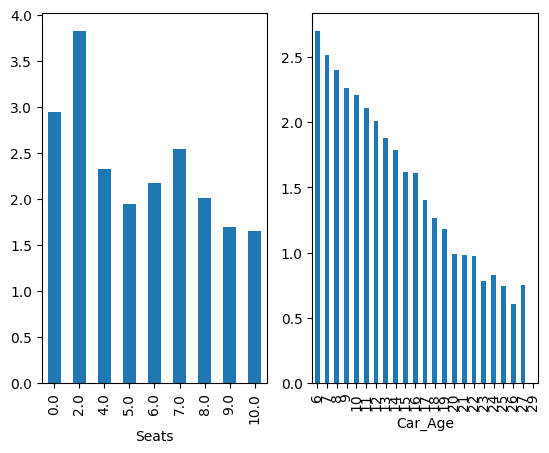

In [ ]:
fig, axarr = plt.subplots(1, 2)
data.groupby('Seats')['Price_log'].mean().plot.bar(ax=axarr[0])
data.groupby('Car_Age')['Price_log'].mean().plot.bar(ax=axarr[1])
plt.show()


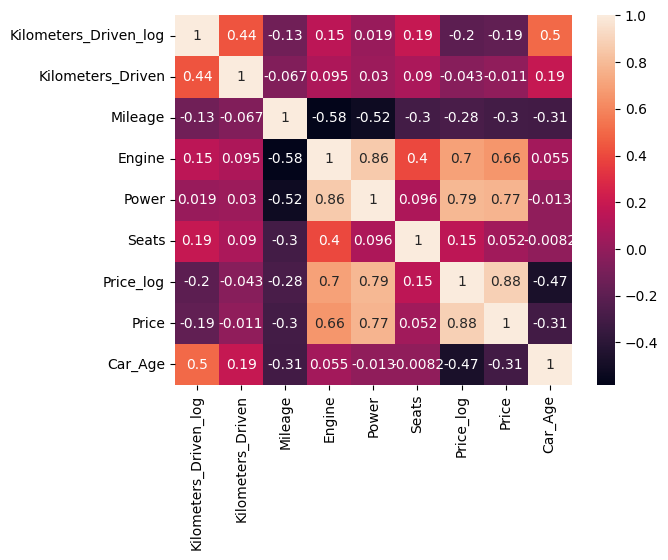

In [ ]:
plt.figure()
sns.heatmap(data[['Kilometers_Driven_log', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price_log',  'Price', 'Car_Age']].corr(), annot = True)
plt.show()


In [ ]:
data.loc[data["Mileage"]==0.0,'Mileage']=np.nan
data.Mileage.isnull().sum()

np.int64(83)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               7253 non-null   object 
 1   Year                   7253 non-null   int64  
 2   Kilometers_Driven      7253 non-null   int64  
 3   Fuel_Type              7253 non-null   object 
 4   Transmission           7253 non-null   object 
 5   Owner_Type             7253 non-null   object 
 6   Mileage                7170 non-null   float64
 7   Engine                 7207 non-null   float64
 8   Power                  7078 non-null   float64
 9   Seats                  7200 non-null   float64
 10  New_Price              1006 non-null   float64
 11  Price                  6019 non-null   float64
 12  Car_Age                7253 non-null   int64  
 13  Brand                  7253 non-null   object 
 14  Model                  7252 non-null   object 
 15  Kilo

In [ ]:
data['Mileage'] = data['Mileage'].fillna(value=np.mean(data['Mileage']))

In [ ]:
median_values = data.groupby(['Model', 'Brand'])['Seats'].transform('median')
data.loc[data['Seats'].isnull(), 'Seats'] = data['Seats'].fillna(median_values)

In [ ]:
median_values = data.groupby(['Model', 'Brand'])['Engine'].transform('median')
data.loc[data['Engine'].isnull(), 'Engine'] = data['Engine'].fillna(median_values)
mean_values = data.groupby(['Model', 'Brand'])['Power'].transform('mean')
data.loc[data['Power'].isnull(), 'Power'] = data['Power'].fillna(mean_values)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               7253 non-null   object 
 1   Year                   7253 non-null   int64  
 2   Kilometers_Driven      7253 non-null   int64  
 3   Fuel_Type              7253 non-null   object 
 4   Transmission           7253 non-null   object 
 5   Owner_Type             7253 non-null   object 
 6   Mileage                7253 non-null   float64
 7   Engine                 7235 non-null   float64
 8   Power                  7190 non-null   float64
 9   Seats                  7231 non-null   float64
 10  New_Price              1006 non-null   float64
 11  Price                  6019 non-null   float64
 12  Car_Age                7253 non-null   int64  
 13  Brand                  7253 non-null   object 
 14  Model                  7252 non-null   object 
 15  Kilo

https://drive.google.com/file/d/1aENPbicbfLDsRw3maE0JJDneRGO1_UYW/view

1. Скачайте файл. Изучите датасет.
2. Выполните первичный анализ датасета (количество строк и столбцов, значения и типы данных, наличие отсутствующих значений, наличие категориальных столбцов, наличие дубликатов строк). Исправьте выявленные ошибки заполнения датасета. При необходимости выполните другие преобразования.
3. Добавьте столбец Sum с суммой всех баллов
Выполните одномерный анализ всех столбцов, включая добавленный
4. Выполните двумерный анализ влияния каждого фактора на столбец Sum
5. Выполните многомерный анализ с помощью цветовой карты корреляционной матрицы.
6. Заполните пропущенные значения наиболее подходящим способом.


# Загрузка данных

In [ ]:
data = pd.read_csv("StudentsPerformance (1).csv")
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,0.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,93.0
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,44.0
4,male,group C,some college,standard,none,76.0,78.0,75.0


# Предобработка данных

In [ ]:
data.shape

(1118, 8)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1118 non-null   object 
 1   race/ethnicity               1117 non-null   object 
 2   parental level of education  1093 non-null   object 
 3   lunch                        1118 non-null   object 
 4   test preparation course      1118 non-null   object 
 5   math score                   1065 non-null   float64
 6   reading score                1056 non-null   float64
 7   writing score                1084 non-null   float64
dtypes: float64(3), object(5)
memory usage: 70.0+ KB


In [ ]:
data.isnull().sum()

,0
gender,0
race/ethnicity,1
parental level of education,25
lunch,0
test preparation course,0
math score,53
reading score,62
writing score,34


In [ ]:
print(data.gender.unique())

['female' 'male']


In [ ]:
print(data['race/ethnicity'].unique())

['group B' 'group C' 'group A' 'group D' 'group E' nan]


In [ ]:
print(data['parental level of education'].unique())

["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school' nan]


In [ ]:
print(data.lunch.unique())

['standard' 'free/reduced']


In [ ]:
print(data['test preparation course'].unique())

['none' 'completed']


In [ ]:
data.duplicated().sum()

np.int64(31)

In [ ]:
data.describe()

,math score,reading score,writing score
count,1065.000000,1056.000000,1084.000000
mean,66.117371,68.871212,68.366236
std,15.265579,14.845699,16.468375
min,0.000000,0.000000,10.000000
25%,57.000000,59.000000,57.000000
50%,66.000000,70.000000,69.000000
75%,76.000000,79.000000,79.000000
max,159.000000,100.000000,263.000000


# Результаты первичного анализа
 - Количество строк 1118 столбцов 8
 - Типы данных:
   - категариальных 5
   - числовых 3
 - Пропуки:
   - race/ethnicity	- 1
   - parental level of education - 	25
   - math score	- 53
   - reading score	- 62
   - writing score	34

- Дубликатов : 31
- Категориальные значения заполнены корректно.

В числовых значениях нет выбросов и скоса данных.


In [ ]:
data= data.drop_duplicates(keep=False)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
cat= ['race/ethnicity', 'parental level of education']
for col in cat:
  data[col].fillna(data[col].mode()[0], inplace = True)

/tmp/ipython-input-2484645801.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace = True)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1056 entries, 0 to 1117
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1056 non-null   object 
 1   race/ethnicity               1056 non-null   object 
 2   parental level of education  1056 non-null   object 
 3   lunch                        1056 non-null   object 
 4   test preparation course      1056 non-null   object 
 5   math score                   1011 non-null   float64
 6   reading score                1008 non-null   float64
 7   writing score                1028 non-null   float64
dtypes: float64(3), object(5)
memory usage: 74.2+ KB


In [ ]:
num= ['math score', 'reading score', 'writing score']
for col in num:
  data[col].fillna(data[col].median(), inplace = True)

/tmp/ipython-input-3508222394.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace = True)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1056 entries, 0 to 1117
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1056 non-null   object 
 1   race/ethnicity               1056 non-null   object 
 2   parental level of education  1056 non-null   object 
 3   lunch                        1056 non-null   object 
 4   test preparation course      1056 non-null   object 
 5   math score                   1056 non-null   float64
 6   reading score                1056 non-null   int64  
 7   writing score                1056 non-null   int64  
 8   Sum                          1056 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 82.5+ KB


In [ ]:
data['writing score']= data['writing score'].astype('int')

In [ ]:
data['reading score']= data['reading score'].astype('int')

In [ ]:
data['reading score']= data['reading score'].astype('int')

#Столбец sum

In [ ]:
data['Sum'] = data['math score']+data['reading score']+data['writing score']
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Sum
0,female,group B,bachelor's degree,standard,none,72.0,0,74,146.0
1,female,group C,some college,standard,completed,69.0,90,88,247.0
2,female,group B,master's degree,standard,none,90.0,95,93,278.0
3,male,group A,associate's degree,free/reduced,none,47.0,57,44,148.0
4,male,group C,some college,standard,none,76.0,78,75,229.0
...,...,...,...,...,...,...,...,...,...
1113,female,group E,some college,free/reduced,none,57.0,58,57,172.0
1114,male,group D,some college,standard,completed,66.0,81,85,232.0
1115,male,group D,some high school,standard,completed,77.0,70,69,216.0
1116,male,group C,master's degree,free/reduced,completed,72.0,66,69,207.0


In [ ]:
data['Sum']= data['Sum'].astype('int')

Выполните одномерный анализ всех столбцов, включая добавленный


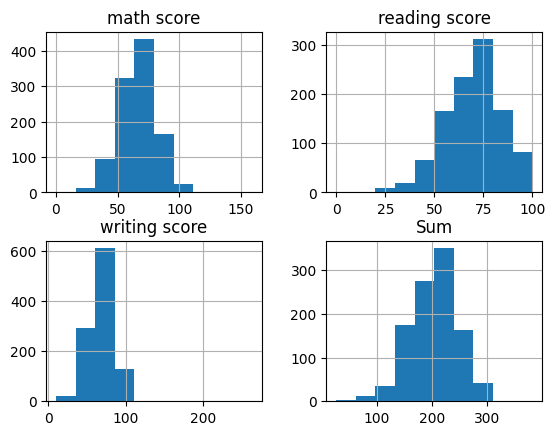

In [ ]:
data.hist()
plt.show()

In [ ]:
cat_cols = ['gender',	'race/ethnicity',	'parental level of education',	'lunch',	'test preparation course']

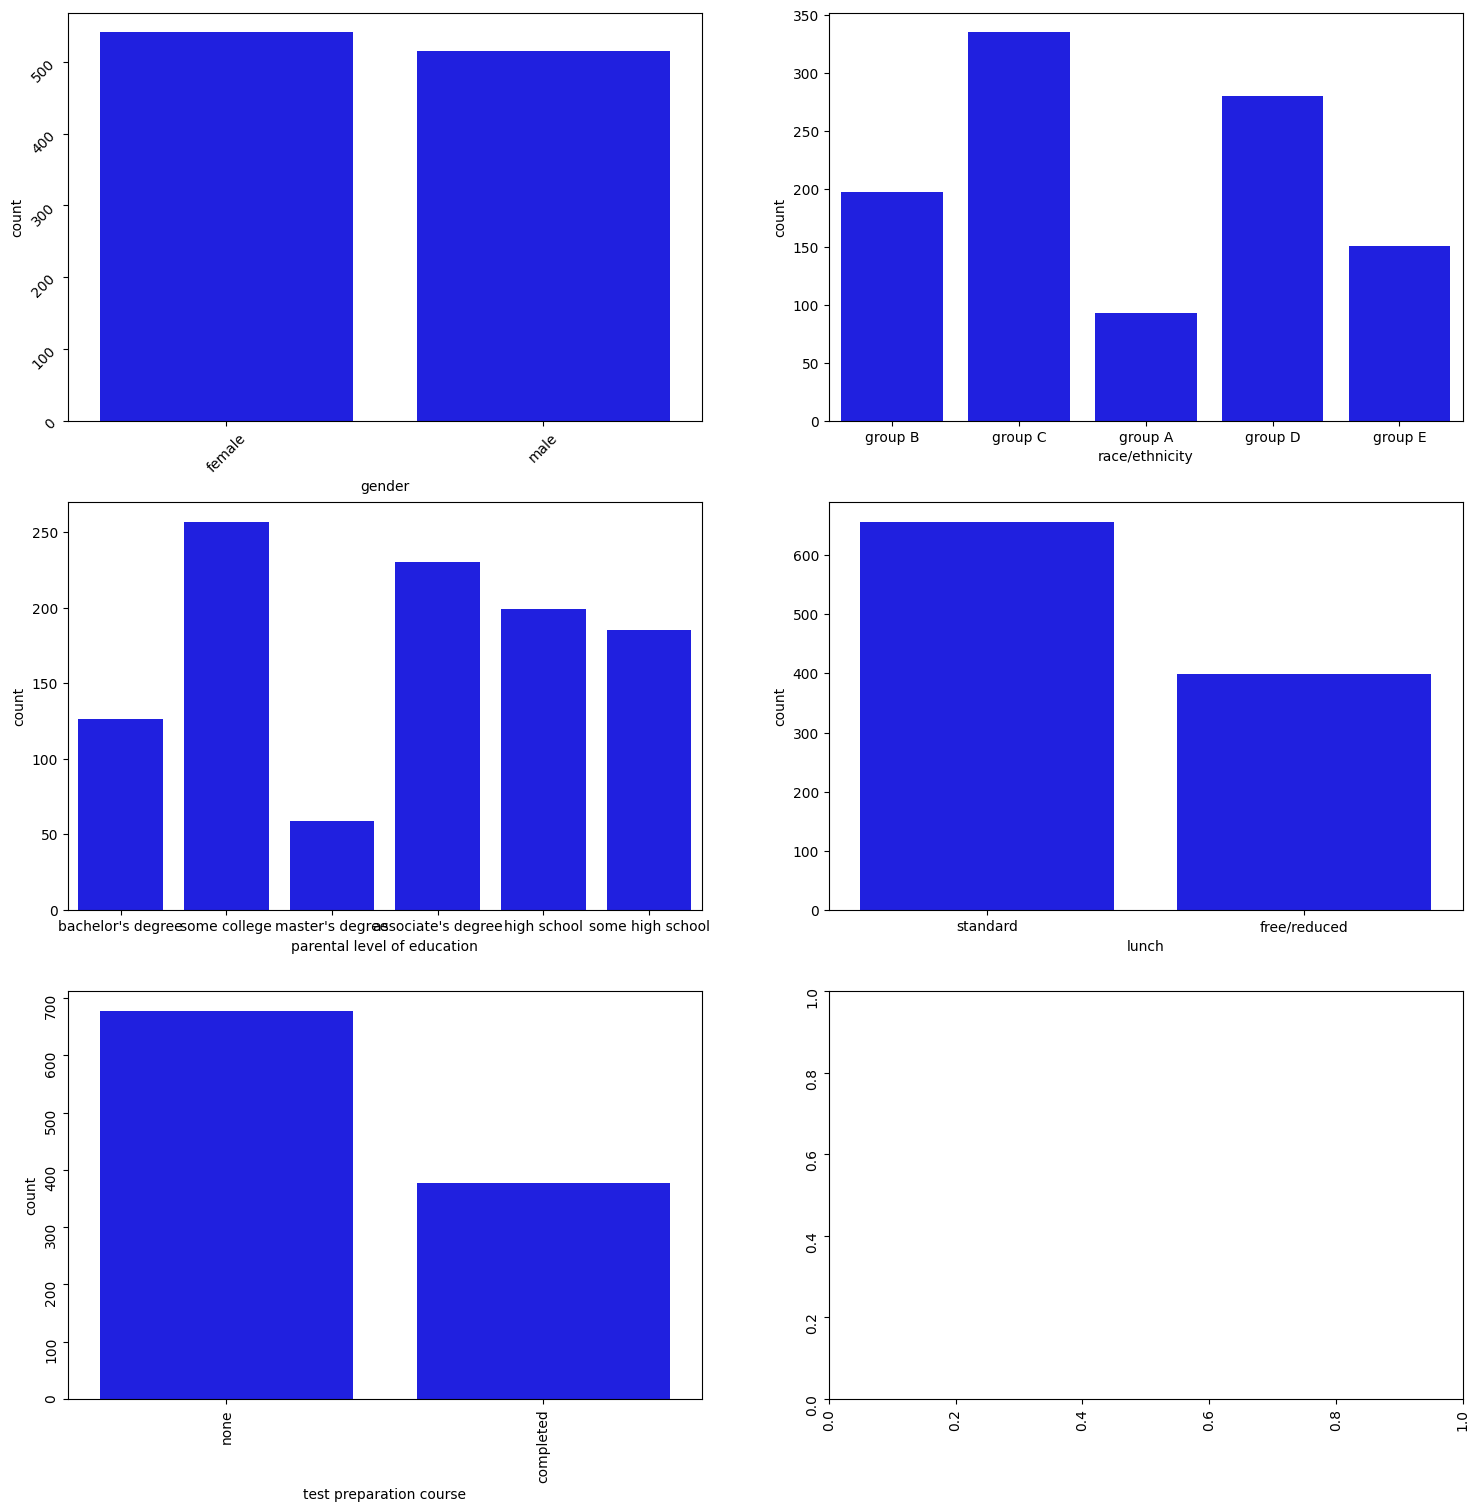

In [ ]:
fig, axes = plt.subplots(3, 2, figsize = (18, 18))
for i in range(len(cat_cols)):
    sns.countplot(ax = axes[i//2, i%2], x = cat_cols[i], data = data, color = 'blue')
axes[0][0].tick_params(labelrotation=45)
axes[2][0].tick_params(labelrotation=90)
axes[2][1].tick_params(labelrotation=90)
plt.show()

Выполните двумерный анализ влияния каждого фактора на столбец Sum


<Figure size 1300x1700 with 0 Axes>

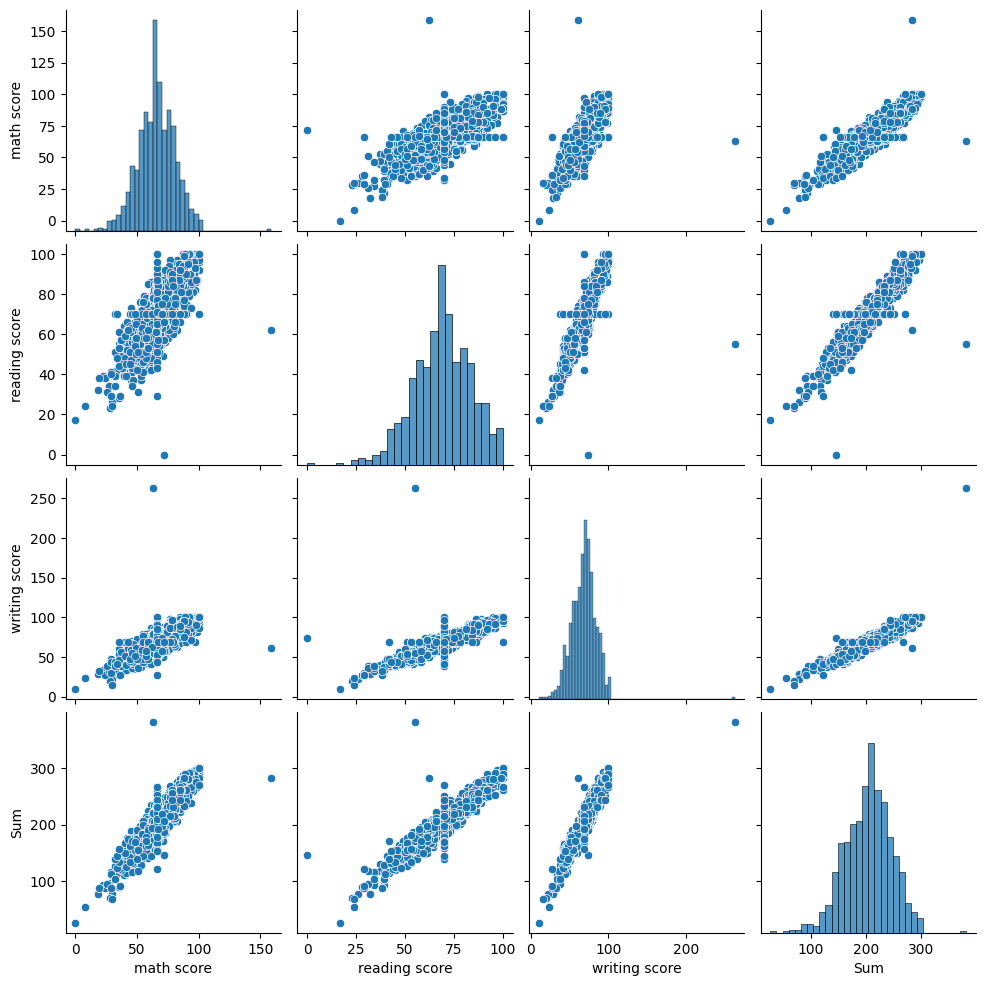

In [ ]:
plt.figure(figsize=(13,17))
sns.pairplot(data)
plt.show()


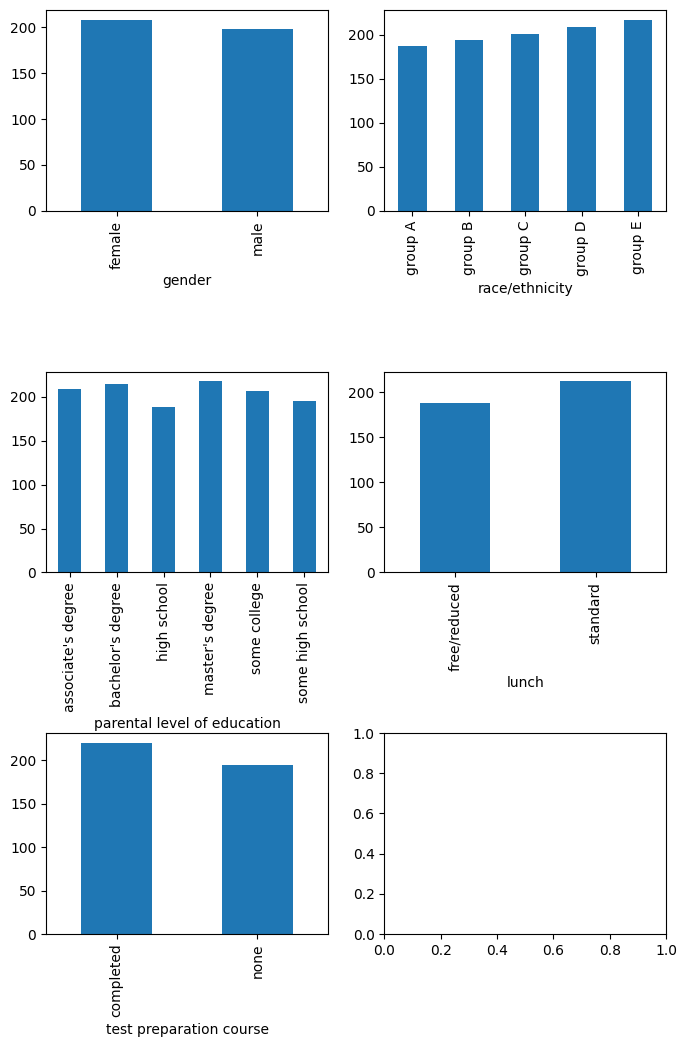

In [ ]:
fig, axarr = plt.subplots(3, 2, figsize=(8, 12))
for i in range(len(cat_cols)):
    data.groupby(cat_cols[i])['Sum'].mean().\
    head(20).plot.bar(ax=axarr[i//2][i%2])
plt.subplots_adjust(hspace=0.8)
plt.show()

Выполните многомерный анализ с помощью цветовой карты корреляционной матрицы.

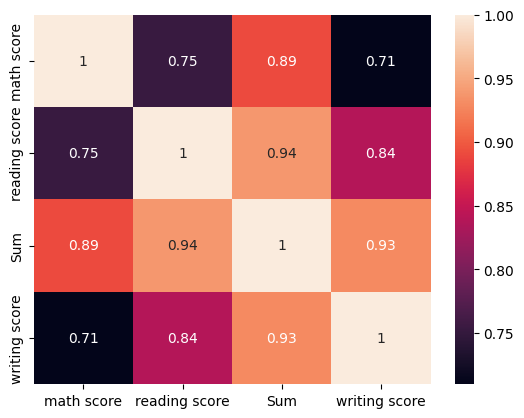

In [ ]:
plt.figure()
sns.heatmap(data[['math score','reading score','Sum', 'writing score']].corr(), annot = True)
plt.show()